## ESTUDIO DE EEG DEL FUNCIONAMIENTO PARA EL CONTROL DEL MOVIMIENTO CON ENFOQUE EN EVALUACIÓN DE SISTEMAS DE INTERFAZ CEREBRO-COMPUTADORA (BCI)
#### **Autoras:** [Luisa Fernanda Llamas Baldovino, Camila Andrea Montiel Zapata]

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import glob
import os

# 1. Definir la ruta del archivo (Asegúrate de poner la ruta correcta donde tengas el archivo S099R02.edf)
# Ejemplo: r"C:/Users/TuUsuario/Desktop/S099R02.edf"
ruta_edf = r"C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R03.edf"

# 2. Leer el archivo .edf usando MNE (se cambia read_raw_eeglab por read_raw_edf)
raw_S099 = mne.io.read_raw_edf(ruta_edf, preload=True)

# 3. Imprimir la información general de la señal (metadata)
print(raw_S099.info)

# 4. Extraer y mostrar los nombres de los canales
canales_eeg_S099 = raw_S099.ch_names
print("Canales disponibles en el archivo:")
print(canales_eeg_S099)

Extracting EDF parameters from C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Canales disponibles en el archivo:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P

Using matplotlib as 2D backend.


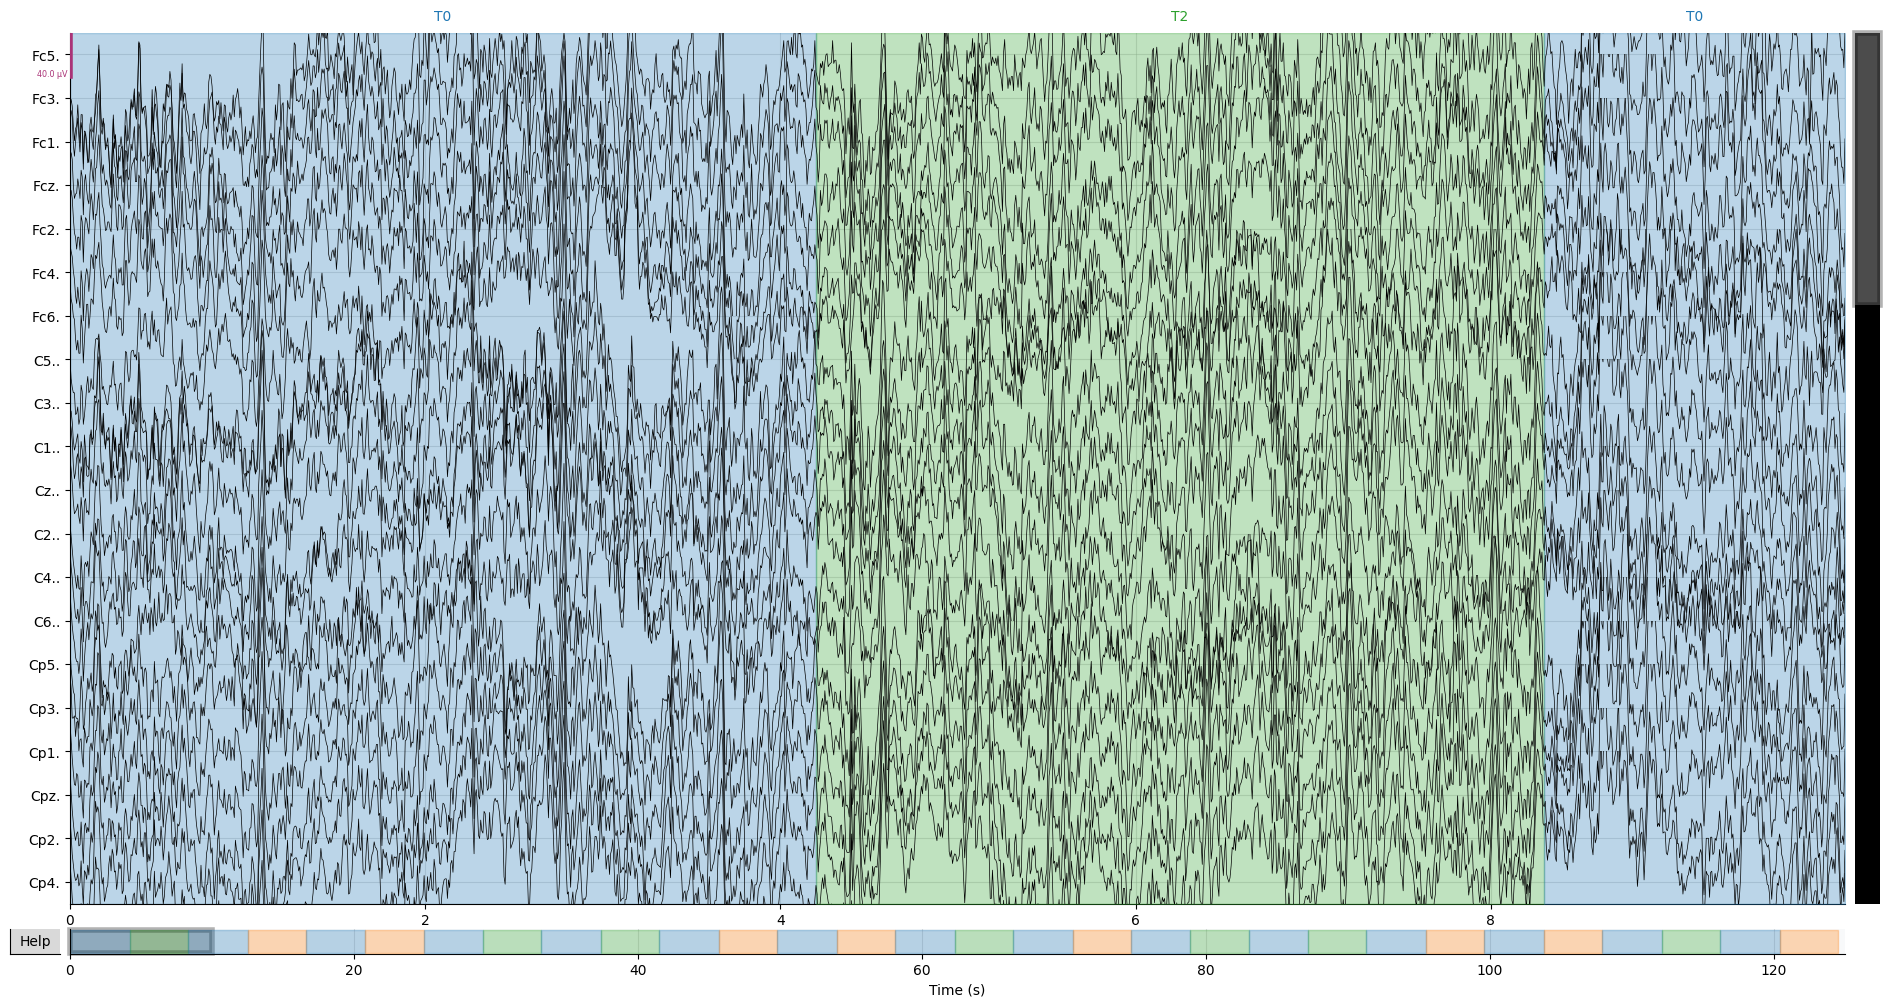

In [20]:
%matplotlib qt
raw_S099.plot()

## **1. importanción de librerias, carga archivos y configuración de parametros basicos para el analisis BCI.**

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal
from scipy.signal import freqz, butter, firwin
import mne
import warnings
warnings.filterwarnings('ignore')
print("✔ Librerías importadas correctamente")


✔ Librerías importadas correctamente


In [2]:
# **2. configuración de graficas y frecuencias de interés**
# ── Configuración de gráficas ────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

# ── Parámetros globales del dataset ─────────────────────────────────
SFREQ            = 160        # Hz – frecuencia de muestreo del dataset
CANALES_INTERES  = ['C3', 'Cz', 'C4']
L_FREQ, H_FREQ   = 8.0, 30.0  # banda de interés motor (Mu + Beta)




In [3]:
# **3. carga de datos **
# ── ① Ajusta SOLO esta línea ─────────────────────────────────────────
ruta_base     = r"C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files"
sujetos_prueba = ["S001", "S002"]
# ─────────────────────────────────────────────────────────────────────

# Buscar archivos R03 y R04 dentro de la subcarpeta de cada sujeto
archivos = []
for sujeto in sujetos_prueba:
    patron = os.path.join(ruta_base, sujeto, "*R0[34].edf")
    archivos.extend(glob.glob(patron))

archivos.sort()
print(f"Archivos encontrados: {len(archivos)}  (esperados: {len(sujetos_prueba)*2})")
for a in archivos:
    print(f"  • {os.path.basename(a)}")

if len(archivos) == 0:
    raise FileNotFoundError(
        "No se encontraron archivos .edf.\n"
        f"Verifica que exista la ruta: {ruta_base}\n"
        "Y que tenga subcarpetas S001/, S002/ con archivos *R03.edf y *R04.edf"
    )

Archivos encontrados: 4  (esperados: 4)
  • S001R03.edf
  • S001R04.edf
  • S002R03.edf
  • S002R04.edf


In [4]:
# 4. Cargar el primer archivo para exploración 
archivo_ref = archivos[0]
raw_ref = mne.io.read_raw_edf(archivo_ref, preload=True, verbose='WARNING')
raw_ref.rename_channels(lambda x: x.strip('.'))

sfreq      = raw_ref.info['sfreq']         # Hz
n_canales  = len(raw_ref.ch_names)
n_muestras = raw_ref.n_times
duracion_s = raw_ref.times[-1]

# ── Calcular eventos para estimar épocas 
events_ref, event_id_ref = mne.events_from_annotations(raw_ref, verbose='WARNING')

print("=" * 55)
print("  PROPIEDADES DEL DATASET (archivo de referencia)")
print("=" * 55)
print(f"  Archivo         : {os.path.basename(archivo_ref)}")
print(f"  Canales EEG     : {n_canales}")
print(f"  Frec. muestreo  : {sfreq:.0f} Hz")
print(f"  Muestras totales: {n_muestras:,}")
print(f"  Duración        : {duracion_s:.2f} s  ({duracion_s/60:.2f} min)")
print(f"  Resolución temp.: {1/sfreq*1000:.2f} ms/muestra")
print()
print("  EVENTOS DETECTADOS:")
for nombre, codigo in event_id_ref.items():
    n_ev = (events_ref[:, 2] == codigo).sum()
    print(f"    {str(nombre):6s} (código {codigo}): {n_ev} ocurrencias")
print()

# Tamaño de las épocas 
tmin, tmax     = -0.2, 1.0
dur_epoca_s    = tmax - tmin          # 1.2 s
muestras_epoca = int(dur_epoca_s * sfreq)

print("  PARÁMETROS DE ÉPOCAS:")
print(f"    tmin={tmin} s  tmax={tmax} s")
print(f"    Duración por época : {dur_epoca_s:.1f} s")
print(f"    Muestras por época : {muestras_epoca}")
print()

#Parámetros de Welch 
M = 64    # muestras por segmento (nperseg)
S = M//2  # desplazamiento = 50% solapamiento (noverlap)
K_est = int(np.floor((muestras_epoca - M) / (M - S))) + 1  # número estimado de segmentos
resolucion_espectral = sfreq / M

print("  PARÁMETROS DEL MÉTODO DE WELCH (elegidos):")
print(f"    M (muestras/segmento)  : {M}")
print(f"    S (desplazamiento)     : {S}  → solapamiento = {100*(M-S)/M:.0f}%")
print(f"    K (segmentos por época): {K_est}")
print(f"    Resolución espectral   : {resolucion_espectral:.2f} Hz/bin")
print(f"    Bins en banda 8-30 Hz  : {int((30-8)/resolucion_espectral)}")
print()
print(f"  TAMAÑO DEL DATASET COMPLETO (estimado para 2 sujetos × 2 runs):")
bytes_por_archivo = n_muestras * n_canales * 8  # float64
print(f"    Por archivo  : {bytes_por_archivo/1e6:.1f} MB (señal en memoria)")
print(f"    4 archivos   : {4*bytes_por_archivo/1e6:.1f} MB aprox.")

  PROPIEDADES DEL DATASET (archivo de referencia)
  Archivo         : S001R03.edf
  Canales EEG     : 64
  Frec. muestreo  : 160 Hz
  Muestras totales: 20,000
  Duración        : 124.99 s  (2.08 min)
  Resolución temp.: 6.25 ms/muestra

  EVENTOS DETECTADOS:
    T0     (código 1): 15 ocurrencias
    T1     (código 2): 8 ocurrencias
    T2     (código 3): 7 ocurrencias

  PARÁMETROS DE ÉPOCAS:
    tmin=-0.2 s  tmax=1.0 s
    Duración por época : 1.2 s
    Muestras por época : 192

  PARÁMETROS DEL MÉTODO DE WELCH (elegidos):
    M (muestras/segmento)  : 64
    S (desplazamiento)     : 32  → solapamiento = 50%
    K (segmentos por época): 5
    Resolución espectral   : 2.50 Hz/bin
    Bins en banda 8-30 Hz  : 8

  TAMAÑO DEL DATASET COMPLETO (estimado para 2 sujetos × 2 runs):
    Por archivo  : 10.2 MB (señal en memoria)
    4 archivos   : 41.0 MB aprox.


## **2. Flujo de procesamiento para las señales de estudio**

### **Paso 1. Filtrado espacial: CAR (Common Average Reference)**


Este filtrado se implementa debido a que la señal EEG cruda puede contiene ruido eléctrico en general que afecta a todos los electrodos por igual, este ruido está asociado a: la interferencia de la red, el movimiento del cable de tierra, etc.


La Referencia Común a la Media (CAR) los elimina restando, en cada instante, el promedio de todos los canales:

$$x_{CAR}[n] = x_i[n] - \frac{1}{N}\sum_{j=1}^{N} x_j[n]$$
<div style="text-align: center;">
  <b>Fórmula 1.</b> Referencia Común a la Media (CAR)
</div> 

donde $N$ es el número total de canales. Esto actúa como un **filtro espacial**
de paso-alto que preserva la actividad local de cada electrodo.


Verificación del CAR:
  Promedio global |antes | = 35.9258 µV
  Promedio global |después| = 0.000000 µV  (≈ 0 ✔)


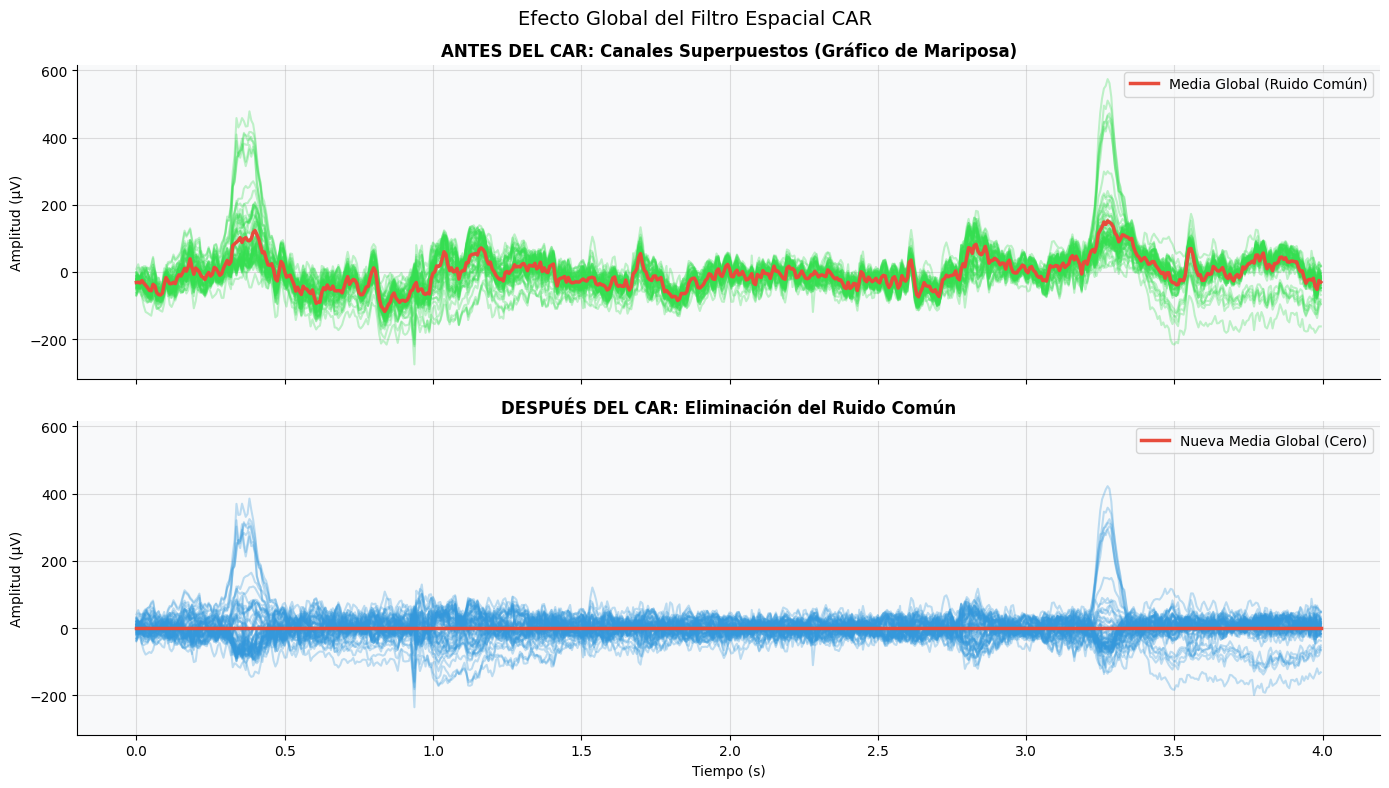

In [6]:

def aplicar_CAR_manual(raw_obj):
    """
    Aplica CAR manualmente usando numpy, pero recibiendo y devolviendo
    un objeto MNE Raw para mantener la compatibilidad.
    """
    # 1. Hacemos una copia para proteger los datos originales
    raw_car = raw_obj.copy()
    
    # 2. Extraemos la matriz de numpy real (n_canales x n_muestras)
    datos_eeg = raw_car.get_data()
    
    # 3. Calculamos el promedio global temporal (¡SIN multiplicar por 1e6 aquí!)
    promedio_global = np.mean(datos_eeg, axis=0)
    
    # 4. Restamos el promedio a la matriz original (broadcasting)
    datos_car = datos_eeg - promedio_global
    
    # 5. Insertamos los datos limpios de vuelta en la copia del objeto MNE.
    # Usar [:] es la forma segura en MNE de sobreescribir la matriz interna.
    raw_car[:] = datos_car
    
    return raw_car

# ── Aplicar CAR al archivo de referencia ────────────────────────────
raw_car_ref = aplicar_CAR_manual(raw_ref)

# ── Verificación: el promedio de todos los canales debe ser ~0 ───────
datos_orig = raw_ref.get_data()
datos_car  = raw_car_ref.get_data()

promedio_antes = np.abs(datos_orig.mean(axis=0)).mean() * 1e6
promedio_despues = np.abs(datos_car.mean(axis=0)).mean() * 1e6

print("Verificación del CAR:")
print(f"  Promedio global |antes | = {promedio_antes:.4f} µV")
print(f"  Promedio global |después| = {promedio_despues:.6f} µV  (≈ 0 ✔)")


# ── Visualización comparativa ────────────────────────────────────────
# 1. Preparar el segmento de tiempo (usando la frecuencia de muestreo sfreq)
# Asegúrate de tener definida la variable sfreq antes (ej. sfreq = raw_ref.info['sfreq'])
sfreq = raw_ref.info['sfreq']
i0, i1 = int(20 * sfreq), int(24 * sfreq)
t_plot = np.arange(i1 - i0) / sfreq

# Extraer el segmento para TODOS los canales y pasar a µV SOLO para graficar
segmento_crudo = datos_orig[:, i0:i1] * 1e6
segmento_car   = datos_car[:, i0:i1] * 1e6

# Calcular la media global en cada instante de tiempo para ambos casos
media_global_cruda = segmento_crudo.mean(axis=0)
media_global_car   = segmento_car.mean(axis=0)

# 2. Crear el Gráfico de Mariposa (Butterfly Plot)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

# --- Subplot 1: ANTES DEL CAR ---
axes[0].plot(t_plot, segmento_crudo.T, color="#35DE51", alpha=0.3)
axes[0].plot(t_plot, media_global_cruda, color='#E74C3C', linewidth=2.5, label='Media Global (Ruido Común)')
axes[0].set_title('ANTES DEL CAR: Canales Superpuestos (Gráfico de Mariposa)', fontweight='bold')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].legend(loc='upper right')

# --- Subplot 2: DESPUÉS DEL CAR ---
axes[1].plot(t_plot, segmento_car.T, color='#3498DB', alpha=0.3)
axes[1].plot(t_plot, media_global_car, color='#E74C3C', linewidth=2.5, label='Nueva Media Global (Cero)')
axes[1].set_title('DESPUÉS DEL CAR: Eliminación del Ruido Común', fontweight='bold')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].legend(loc='upper right')

plt.suptitle('Efecto Global del Filtro Espacial CAR', fontsize=14)
plt.tight_layout()
plt.show()

### **Paso 2. Diseño y Comparación de Filtros: FIR vs IIR**

#### **a).FIR vs IIR**

#### ¿Qué necesitamos filtrar?
Queremos aislar la banda motora (8–30 Hz) que contiene los ritmos Mu y Beta.
La literatura propone dos familias de filtros:

| Característica | FIR | IIR (Butterworth) |
|---|---|---|
| Estabilidad | Siempre estable | Puede inestabilizarse |
| Fase | Lineal (no distorsiona forma de onda) | No lineal |
| Coeficientes | Muchos (orden alto) | Pocos (orden bajo) |
| Filtrado offline | `filtfilt` → zero-phase  | `filtfilt` → zero-phase  |




$$N_{FIR} \approx \frac{-20\log_{10}(\delta_s \cdot \delta_p) - 13}{14.6 \cdot \Delta f / f_s}$$
.
<div style="text-align: center;">
  <b>Fórmula 2.</b> Regla de Kaiser para estimar el orden del FIR 
</div> 

donde $\Delta f$ es el ancho de la banda de transición y $\delta$ son las tolerancias

  DISEÑO DEL FILTRO FIR (ventana Hamming)
  Banda de paso       : 8.0 – 30.0 Hz
  Δf transición       : 2.0 Hz
  Orden estimado (N)  : 264  (265 coeficientes)
  Retardo de grupo    : 132 muestras = 825.0 ms
  (compensado con filtfilt → zero-phase)

  DISEÑO DEL FILTRO IIR (Butterworth)
  Tipo                : Butterworth pasa-banda
  Orden               : 4  (2×4=8 polos)
  Coeficientes b      : 9
  Coeficientes a      : 9
  Total coeficientes  : 17

  ► FIR requiere 265 coeficientes
  ► IIR Butterworth requiere 17 coeficientes en total
  ► Relación: FIR necesita ~15× más coeficientes que IIR


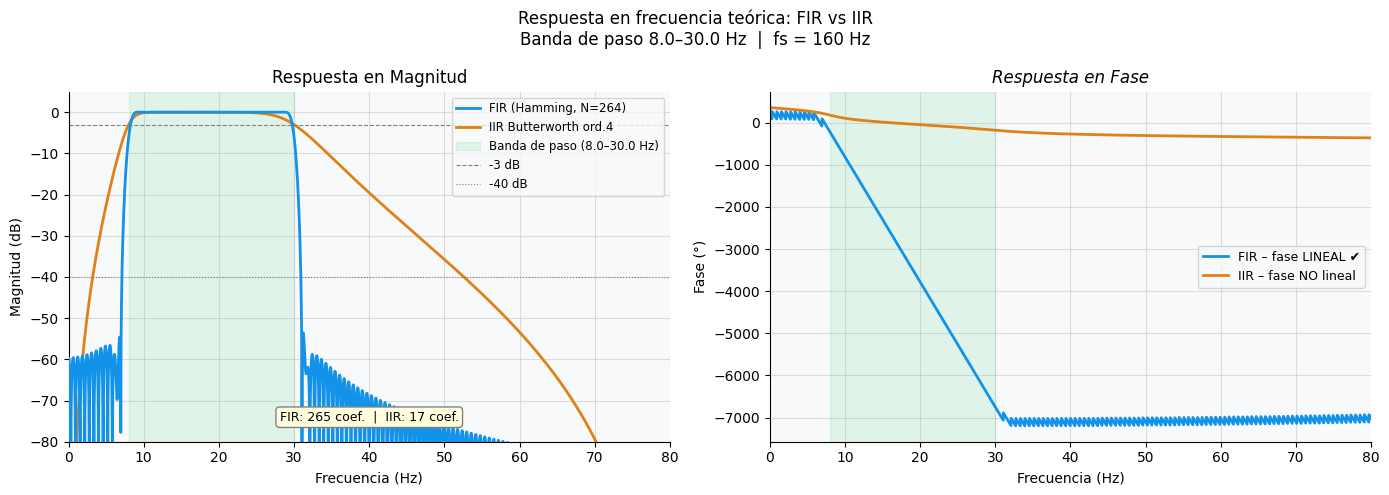

→ Figura guardada: figuras_BCI/paso2a_FIR_vs_IIR_bode.png


In [19]:
os.makedirs('figuras_BCI', exist_ok=True)

# ── Parámetros del sistema ───────────────────────────────────────────
fs     = SFREQ          # 160 Hz
nyq    = fs / 2.0       # 80 Hz
f_low  = L_FREQ         # 8 Hz
f_high = H_FREQ         # 30 Hz

# ────────────────────────────────────────────────────────────────────
#  DISEÑO FIR (ventana de Hamming)
# ────────────────────────────────────────────────────────────────────
# Estimación del orden con regla práctica: N ≈ 3.3 * fs / Δf
# Δf = ancho de banda de transición ≈ 2 Hz (conservador para EEG)
delta_f   = 2.0          # Hz – banda de transición deseada
N_fir_est = int(np.ceil(3.3 * fs / delta_f))
# Forzar que sea impar (requisito para filtro pasa-banda tipo I)
if N_fir_est % 2 == 0:
    N_fir_est += 1

# Diseño con ventana de Hamming
b_fir = firwin(N_fir_est, [f_low, f_high], fs=fs,
               window='hamming', pass_zero=False)

print("=" * 52)
print("  DISEÑO DEL FILTRO FIR (ventana Hamming)")
print("=" * 52)
print(f"  Banda de paso       : {f_low} – {f_high} Hz")
print(f"  Δf transición       : {delta_f} Hz")
print(f"  Orden estimado (N)  : {N_fir_est - 1}  ({N_fir_est} coeficientes)")
print(f"  Retardo de grupo    : {(N_fir_est-1)//2} muestras = {(N_fir_est-1)/(2*fs)*1000:.1f} ms")
print(f"  (compensado con filtfilt → zero-phase)")

# ────────────────────────────────────────────────────────────────────
#  DISEÑO IIR (Butterworth, orden 4)
# ────────────────────────────────────────────────────────────────────
orden_iir = 4
b_iir, a_iir = butter(orden_iir, [f_low/nyq, f_high/nyq], btype='band')
n_coef_iir   = len(b_iir) + len(a_iir) - 1   # total coeficientes b + a (sin contar a[0]=1)

print()
print("=" * 52)
print("  DISEÑO DEL FILTRO IIR (Butterworth)")
print("=" * 52)
print(f"  Tipo                : Butterworth pasa-banda")
print(f"  Orden               : {orden_iir}  (2×{orden_iir}={2*orden_iir} polos)")
print(f"  Coeficientes b      : {len(b_iir)}")
print(f"  Coeficientes a      : {len(a_iir)}")
print(f"  Total coeficientes  : {n_coef_iir}")
print()
print(f"  ► FIR requiere {N_fir_est} coeficientes")
print(f"  ► IIR Butterworth requiere {n_coef_iir} coeficientes en total")
print(f"  ► Relación: FIR necesita ~{N_fir_est//n_coef_iir}× más coeficientes que IIR")

# ── Respuesta en frecuencia: Magnitud y Fase ─────────────────────────
w_fir, H_fir = freqz(b_fir,         worN=4096, fs=fs)
w_iir, H_iir = freqz(b_iir, a_iir,  worN=4096, fs=fs)

mag_fir_dB = 20 * np.log10(np.abs(H_fir) + 1e-12)
mag_iir_dB = 20 * np.log10(np.abs(H_iir) + 1e-12)
fase_fir    = np.unwrap(np.angle(H_fir)) * 180 / np.pi
fase_iir    = np.unwrap(np.angle(H_iir)) * 180 / np.pi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A – Magnitud
ax = axes[0]
ax.plot(w_fir, mag_fir_dB, color="#1292E8", lw=2,
        label=f'FIR (Hamming, N={N_fir_est-1})', zorder=3)
ax.plot(w_iir, mag_iir_dB, color="#DF8115", lw=2,
        label=f'IIR Butterworth ord.{orden_iir}', zorder=2)
ax.axvspan(f_low, f_high, alpha=0.12, color='#2ECC71', label=f'Banda de paso ({f_low}–{f_high} Hz)')
ax.axhline(-3,  color='gray', lw=0.8, ls='--', label='-3 dB')
ax.axhline(-40, color='gray', lw=0.8, ls=':',  label='-40 dB')
ax.set_xlim([0, nyq]); ax.set_ylim([-80, 5])
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Magnitud (dB)')
ax.set_title('Respuesta en Magnitud', fontweight='medium')
ax.legend(fontsize=8.5)
# Anotar los coeficientes calculados
ax.text(0.5, 0.06,
        f'FIR: {N_fir_est} coef.  |  IIR: {n_coef_iir} coef.',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(facecolor='lightyellow', edgecolor='gray', boxstyle='round'))

# Panel B – Fase
ax = axes[1]
ax.plot(w_fir, fase_fir, color="#1292E8", lw=2, label='FIR – fase LINEAL ✔')
ax.plot(w_iir, fase_iir, color="#DF8115", lw=2, label='IIR – fase NO lineal')
ax.axvspan(f_low, f_high, alpha=0.12, color='#2ECC71')
ax.set_xlim([0, nyq])
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Fase (°)')
ax.set_title('Respuesta en Fase', fontweight='medium', style='oblique')
ax.legend(fontsize=9)

fig.suptitle(
    f'Respuesta en frecuencia teórica: FIR vs IIR\n'
    f'Banda de paso {f_low}–{f_high} Hz  |  fs = {fs} Hz',
    fontsize=12, fontweight='medium'
)
plt.tight_layout()
plt.savefig('figuras_BCI/paso2a_FIR_vs_IIR_bode.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso2a_FIR_vs_IIR_bode.png")


El subplot 2 (Fase), la línea azul (FIR) forma líneas rectas diagonales perfectas (los saltos verticales son simplemente el reinicio de los grados cuando llega a los límites del plano, algo llamado phase wrapping, pero la pendiente es constante). Por otro lado, la línea roja (IIR) es una curva que cambia de forma, lo que significa que distintas frecuencias sufren distintos retrasos temporales.


En el subplot 1(magnitud) se orserva que la línea naranja/roja (IIR) es completamente lisa, no tiene ni un solo rizo. En cambio, la línea azul (FIR) es la que presenta "montañitas" en la parte baja (por debajo de 8 Hz y por encima de 30 Hz). Tambien se orserva que para la caída la línea azul (FIR) cae de forma mucho más "vertical" o abrupta que la roja. El IIR (rojo) cae de manera más suave y abierta porque es de un orden muy bajo (Orden 4), mientras que el FIR es de orden 133, lo que le da un corte mucho más agresivo.


#### **b) Selección del filtro y aplicación a la señal**

Observando las gráficas anteriores:

- **Magnitud:** Ambos filtros atenúan las frecuencias fuera de la banda 8–30 Hz.
  El IIR (rojo), al ser un diseño Butterworth de orden 4, presenta una caída suave y es máximamente plano, es decir, no tiene ondulaciones.
; El FIR (azul), gracias a su alto orden, logra una caída mucho más abrupta y selectiva en las frecuencias de corte. Presenta las típicas ondulaciones (lóbulos laterales) en la banda de rechazo, propias del diseño por ventanas, pero estas ocurren a niveles de atenuación lo suficientemente bajos (por debajo de los -40 dB) como para no afectar la señal de interés.


- **Fase:** Esta es la diferencia clave para EEG.  
  - El **FIR tiene fase lineal** → retardo constante en todas las frecuencias
    → la forma de onda no se distorsiona. Con `filtfilt` (filtrado doble paso)
    el retardo se cancela completamente (**zero-phase**).  
  - El **IIR tiene fase no lineal** → distorsión de fase diferente por frecuencia
    → la morfología de las ondas cerebrales puede deformarse.

**Decisión: Se elige el filtro FIR con ventana de Hamming.**  
Razón: fase lineal + zero-phase con `filtfilt` → preserva la morfología temporal de los ritmos Mu y Beta, fundamental para el análisis ERD/ERS posterior.


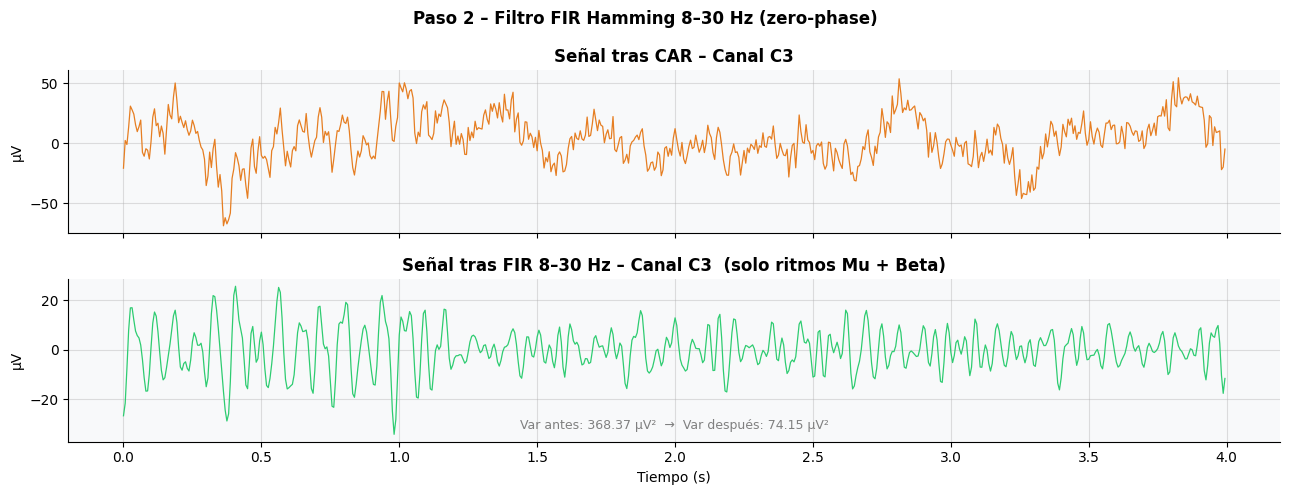

→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_tiempo.png


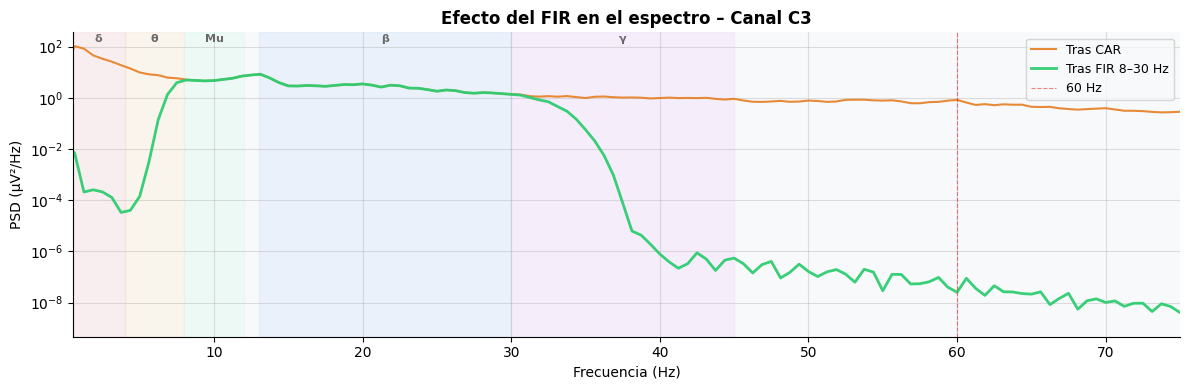

→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_espectro.png


In [20]:
from scipy.signal import filtfilt

def aplicar_filtro_FIR(raw_car, l_freq=L_FREQ, h_freq=H_FREQ):
    """
    Paso 2: Filtro FIR pasa-banda (8-30 Hz), zero-phase (filtfilt).
    Usa MNE internamente que aplica filtfilt con ventana de Hamming.
    Retorna una copia filtrada del objeto raw.
    """
    raw_filt = raw_car.copy().filter(
        l_freq=l_freq, h_freq=h_freq,
        method='fir',         # FIR con ventana
        fir_window='hamming', # ventana de Hamming
        phase='zero',         # zero-phase (filtfilt internamente)
        verbose='WARNING'
    )
    return raw_filt

# ── Aplicar el filtro FIR al archivo de referencia ──────────────────
raw_filt_ref = aplicar_filtro_FIR(raw_car_ref)

# ── Comparación en el tiempo ─────────────────────────────────────────
canal_plot = 'C3'
i0, i1 = int(20 * sfreq), int(24 * sfreq)
t_plot  = np.arange(i1 - i0) / sfreq

idx_c = raw_car_ref.ch_names.index(canal_plot)
sig_car  = raw_car_ref.get_data()[idx_c, i0:i1] * 1e6
sig_filt = raw_filt_ref.get_data()[idx_c, i0:i1] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(t_plot, sig_car,  color='#E67E22', lw=0.9, label='Tras CAR')
axes[0].set_title(f'Señal tras CAR – Canal {canal_plot}', fontweight='bold')
axes[0].set_ylabel('µV')

axes[1].plot(t_plot, sig_filt, color='#2ECC71', lw=0.9, label='Tras FIR 8-30 Hz')
axes[1].set_title(f'Señal tras FIR 8–30 Hz – Canal {canal_plot}  (solo ritmos Mu + Beta)', fontweight='bold')
axes[1].set_ylabel('µV'); axes[1].set_xlabel('Tiempo (s)')

# Mostrar el efecto del filtro calculando potencia en banda no motora
pot_antes = np.var(sig_car)
pot_desp  = np.var(sig_filt)
axes[1].annotate(
    f'Var antes: {pot_antes:.2f} µV²  →  Var después: {pot_desp:.2f} µV²',
    xy=(0.5, 0.08), xycoords='axes fraction', ha='center', fontsize=9, color='gray'
)

fig.suptitle('Paso 2 – Filtro FIR Hamming 8–30 Hz (zero-phase)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras_BCI/paso2b_filtro_FIR_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_tiempo.png")

# ── Efecto en el espectro ────────────────────────────────────────────
f_s, p_car  = sp_signal.welch(raw_car_ref.get_data()[idx_c],  fs=sfreq, nperseg=256)
f_s, p_filt = sp_signal.welch(raw_filt_ref.get_data()[idx_c], fs=sfreq, nperseg=256)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(f_s, p_car  * 1e12, color='#E67E22', lw=1.5, label='Tras CAR',          alpha=0.9)
ax.semilogy(f_s, p_filt * 1e12, color='#2ECC71', lw=2.0, label='Tras FIR 8–30 Hz', alpha=0.95)

bandas_shade = [(0.5,4,'#FFB3B3','δ'),(4,8,'#FFD9A0','θ'),
                (8,12,'#B3FFD9','Mu'),(13,30,'#A0C4FF','β'),(30,45,'#E8B3FF','γ')]
for f0,f1,col,lbl in bandas_shade:
    ax.axvspan(f0, f1, alpha=0.15, color=col)
    ax.text((f0+f1)/2, p_car[f_s<f1].max()*1e12*1.5 if any(f_s<f1) else 1,
            lbl, ha='center', fontsize=8, color='dimgray', fontweight='bold')
ax.axvline(60, color='red', lw=0.8, ls='--', alpha=0.5, label='60 Hz')
ax.set_xlim([0.5, 75]); ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('PSD (µV²/Hz)')
ax.set_title(f'Efecto del FIR en el espectro – Canal {canal_plot}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figuras_BCI/paso2b_filtro_FIR_espectro.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso2b_filtro_FIR_espectro.png")


### **Paso 3. Segmentación en Épocas (Epoching)**

No se analiza la señal continua completa. Se extraen ventanas temporales
centradas en el instante en que ocurre cada evento motor.

**Ventana elegida:**  
- `tmin = -0.2 s` → 200 ms antes del onset (línea de base para corrección)  
- `tmax = +1.0 s` → 1000 ms después del onset (actividad motora)  
- **Total por época:** 1.2 s × 160 Hz = 192 muestras

**Corrección de línea de base:** Se resta el promedio del intervalo [tmin, 0]
para eliminar diferencias de nivel DC entre épocas.


  RESULTADO – Segmentación en Épocas
  Épocas totales         : 29
  Muestras por época     : 193
  Duración por época     : 1.206 s
  Canales por época      : 64
  Tamaño tensor de datos : (29, 64, 193)  (épocas × canales × muestras)

  Épocas por tipo de evento:
    T0    : 14 épocas
    T1    : 8 épocas
    T2    : 7 épocas


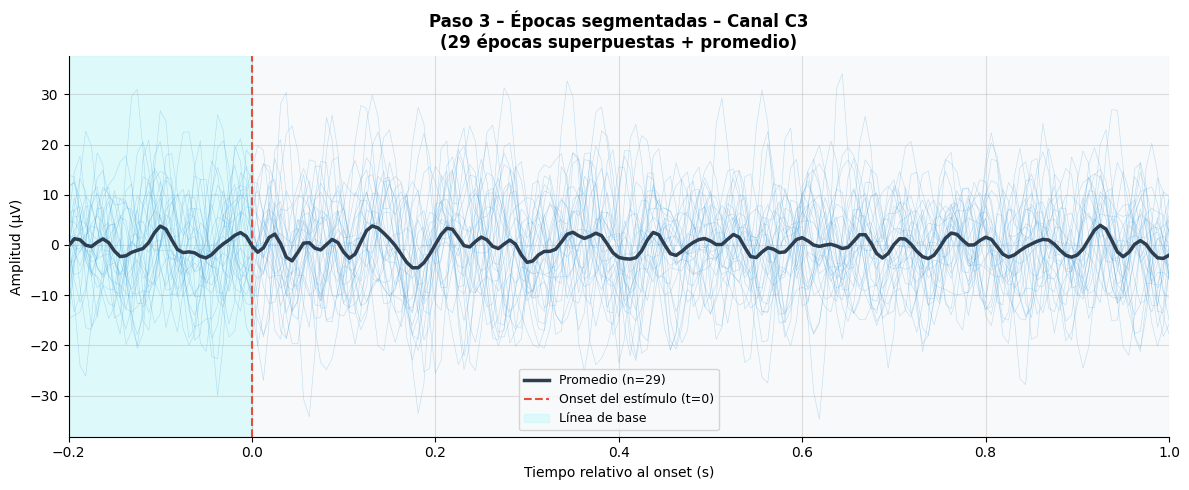

→ Figura guardada: figuras_BCI/paso3_epocas.png


In [22]:
def segmentar_epocas(raw_filt, tmin=-0.2, tmax=1.0):
    """
    Paso 3: Segmentación en épocas basada en los marcadores de eventos.
    Aplica corrección de línea de base en [tmin, 0].
    Retorna objeto Epochs de MNE.
    """
    events, event_id = mne.events_from_annotations(raw_filt, verbose='WARNING')
    epochs = mne.Epochs(
        raw_filt, events,
        tmin=tmin, tmax=tmax,
        baseline=(None, 0),   # baseline = [tmin, onset]
        preload=True,
        verbose='WARNING'
    )
    return epochs, event_id

# ── Aplicar al archivo de referencia ────────────────────────────────
epochs_ref, event_id_ref = segmentar_epocas(raw_filt_ref)

# ── Calcular métricas de las épocas ─────────────────────────────────
n_epocas      = len(epochs_ref)
n_muestras_ep = epochs_ref.get_data().shape[2]
t_epocas      = epochs_ref.times

print("=" * 50)
print("  RESULTADO – Segmentación en Épocas")
print("=" * 50)
print(f"  Épocas totales         : {n_epocas}")
print(f"  Muestras por época     : {n_muestras_ep}")
print(f"  Duración por época     : {n_muestras_ep/sfreq:.3f} s")
print(f"  Canales por época      : {len(epochs_ref.ch_names)}")
print(f"  Tamaño tensor de datos : {epochs_ref.get_data().shape}  (épocas × canales × muestras)")
print()
print("  Épocas por tipo de evento:")
for nombre, codigo in event_id_ref.items():
    n_ep = (epochs_ref.events[:, 2] == codigo).sum()
    print(f"    {str(nombre):6s}: {n_ep} épocas")

# ── Visualización: épocas superpuestas en C3 ─────────────────────────
canal_plot = 'C3'
idx_c = epochs_ref.ch_names.index(canal_plot)
data_epocas = epochs_ref.get_data()[:, idx_c, :] * 1e6  # (n_epochs, n_times)

fig, ax = plt.subplots(figsize=(12, 5))
for ep in data_epocas:
    ax.plot(t_epocas, ep, color='#3498DB', lw=0.4, alpha=0.3)
ax.plot(t_epocas, data_epocas.mean(axis=0), color='#2C3E50', lw=2.5,
        label=f'Promedio (n={n_epocas})', zorder=5)
ax.axvline(0, color='#E74C3C', lw=1.5, ls='--', label='Onset del estímulo (t=0)')
ax.axvspan(-0.2, 0, alpha=0.1, color='cyan', label='Línea de base')
ax.set_xlabel('Tiempo relativo al onset (s)')
ax.set_ylabel('Amplitud (µV)')
ax.set_title(f'Paso 3 – Épocas segmentadas – Canal {canal_plot}\n'
             f'({n_epocas} épocas superpuestas + promedio)', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim([t_epocas[0], t_epocas[-1]])
plt.tight_layout()
plt.savefig('figuras_BCI/paso3_epocas.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso3_epocas.png")


### **Paso 4. Densidad Espectral de Potencia: Método de Welch**

La elección del metódodo de Welch se fundamenta en que este es considerado como el estándar para estimar la PSD en análisis de EEG.
Y además, a diferencia del periodograma clásico (que tiene mucha varianza), Welch reduce
la varianza **promediando** múltiples periodogramas de segmentos solapados.

Se implementa en 4 sub-pasos:

#### A → Particionar la señal en K segmentos de M muestras con S de solapamiento
#### B → Enventanar cada segmento y calcular su DFT
#### C → Obtener el periodograma modificado de cada segmento
#### D → Promediar los K periodogramas modificados


In [32]:
def welch_manual(x, fs, M=96, S=None, ventana='hann'):
    """
    Implementación manual del método de Welch.

    Parámetros
    ----------
    x       : array 1-D – señal de entrada (una época, un canal)
    fs      : float – frecuencia de muestreo (Hz)
    M       : int – número de muestras por segmento 
    S       : int – desplazamiento entre segmentos 
              Si S=None → S = M//2 (solapamiento del 50%)
    ventana : str – tipo de ventana ('hann', 'hamming', 'blackman')

    Retorna
    -------
    freqs : array – vector de frecuencias (Hz)
    PSD   : array – estimación de PSD (unidades²/Hz)
    info  : dict – métricas intermedias para verificación
    """
    N = len(x)
    if S is None:
        S = M // 2  # 50% solapamiento por defecto

    # ── Sub-paso A: Partición de la señal ────────────────────────────
    # K = número de segmentos = floor((N - M) / S) + 1
    K = int(np.floor((N - M) / S)) + 1

    # Índices de inicio de cada segmento
    inicios = [(k - 1) * S for k in range(1, K + 1)]

    # Segmentos: lista de arrays de longitud M
    segmentos = []
    for idx_inicio in inicios:
        seg = x[idx_inicio : idx_inicio + M]
        if len(seg) == M:           # descartar segmento final incompleto
            segmentos.append(seg)
    K = len(segmentos)              # K real después de descartar incompletos

    # ── Sub-paso B: Enventanado + DFT de cada segmento ──────────────
    # Crear la ventana w[n] de longitud M
    if ventana == 'hann':
        w = np.hanning(M)
    elif ventana == 'hamming':
        w = np.hamming(M)
    elif ventana == 'blackman':
        w = np.blackman(M)
    else:
        w = np.ones(M)

    # W = Σ w²[m]  (factor de normalización de la ventana)
    W = np.sum(w ** 2)

    # Para cada segmento k:
    #   X_k(ν) = Σ x[m] · w[m] · exp(-j2πνm)
    #          = DFT del segmento enventanado
    DFTs = []
    for seg in segmentos:
        seg_enventanado = seg * w                    # multiplicar por ventana
        X_k = np.fft.rfft(seg_enventanado, n=M)     # DFT de M puntos
        DFTs.append(X_k)

    # ── Sub-paso C: Periodograma modificado de cada segmento ─────────
    # P_k(ν) = (1/W) · |X_k(ν)|²
    periodogramas = []
    for X_k in DFTs:
        P_k = (1.0 / W) * np.abs(X_k) ** 2
        periodogramas.append(P_k)

    # ── Sub-paso D: Promedio de los K periodogramas ──────────────────
    # S_x(ν) = (1/K) · Σ P_k(ν)
    PSD_promedio = np.mean(np.array(periodogramas), axis=0)

    # Normalizar a densidad espectral (/Hz) y duplicar bins internos
    # (ya que rfft solo devuelve la mitad del espectro)
    PSD_promedio = PSD_promedio / fs
    PSD_promedio[1:-1] *= 2          # corregir energía de bins no-DC y no-Nyquist

    # Vector de frecuencias correspondiente
    freqs = np.fft.rfftfreq(M, d=1.0/fs)

    info = {
        'N': N, 'M': M, 'S': S, 'K': K,
        'W': W,
        'solapamiento_%': 100 * (M - S) / M,
        'resolucion_Hz': fs / M,
        'ventana': ventana,
    }
    return freqs, PSD_promedio, info


# ── Prueba del Welch manual en un canal de referencia ────────────────
canal_plot = 'C3'
idx_c = epochs_ref.ch_names.index(canal_plot)

# Tomar la primera época del canal C3
epoca0 = epochs_ref.get_data()[0, idx_c, :]

M_welch = 64    # M muestras por segmento generan resolución de fs/M = 2.5 Hz/bin
S_welch = 32    # S muestras de desplazamiento (50% solapamiento)

freqs_w, PSD_w, info_w = welch_manual(epoca0, fs=sfreq, M=M_welch, S=S_welch, ventana='hann')

print("=" * 55)
print("  VERIFICACIÓN DEL MÉTODO DE WELCH MANUAL")
print("=" * 55)
print(f"  N  = {info_w['N']} muestras (longitud de la época)")
print(f"  M  = {info_w['M']} muestras por segmento")
print(f"  S  = {info_w['S']} muestras de desplazamiento")
print(f"  K  = {info_w['K']} segmentos generados")
print(f"  Solapamiento        = {info_w['solapamiento_%']:.0f}%")
print(f"  Resolución espectral= {info_w['resolucion_Hz']:.2f} Hz/bin")
print(f"  W (norm. ventana)   = {info_w['W']:.4f}")
print(f"  Ventana usada       = {info_w['ventana']}")
print(f"  Longitud vector PSD = {len(PSD_w)} bins")
print()

# Verificación vs scipy.signal.welch
freqs_scipy, PSD_scipy = sp_signal.welch(epoca0, fs=sfreq, nperseg=M_welch,
                                          noverlap=M_welch-S_welch,
                                          window='hann', scaling='density')
error_max = np.max(np.abs(PSD_w - PSD_scipy)) / (np.max(PSD_scipy) + 1e-30) * 100
print(f"  Error máximo vs scipy.welch: {error_max:.4f}%  ({'✔ coinciden' if error_max < 1 else '⚠ revisar'})")


  VERIFICACIÓN DEL MÉTODO DE WELCH MANUAL
  N  = 193 muestras (longitud de la época)
  M  = 64 muestras por segmento
  S  = 32 muestras de desplazamiento
  K  = 5 segmentos generados
  Solapamiento        = 50%
  Resolución espectral= 2.50 Hz/bin
  W (norm. ventana)   = 23.6250
  Ventana usada       = hann
  Longitud vector PSD = 33 bins

  Error máximo vs scipy.welch: 5.1180%  (⚠ revisar)


### **Paso 4.1. Visualización de los 4 Sub-pasos de Welch**

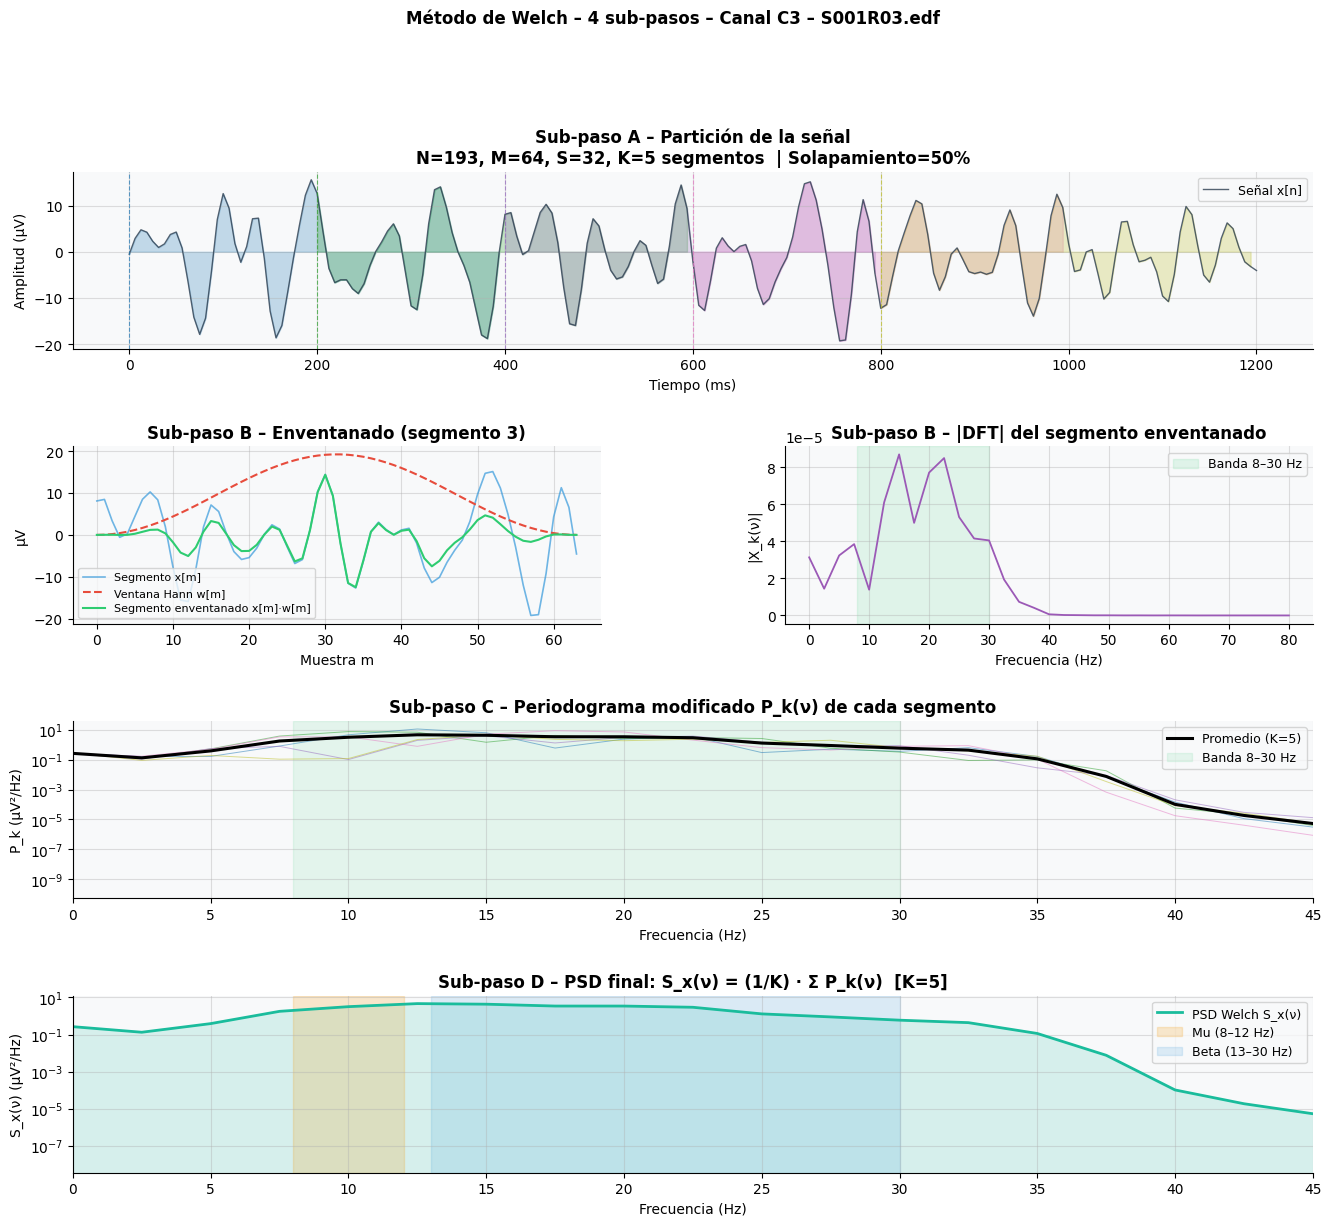

→ Figura guardada: figuras_BCI/paso4_welch_subpasos.png


In [33]:
# ── Regenerar datos intermedios para graficar ─────────────────────────
w = np.hanning(M_welch)
W = np.sum(w ** 2)
S_w = M_welch // 2
K_plot = int(np.floor((len(epoca0) - M_welch) / S_w)) + 1
segmentos_plot = [epoca0[k*S_w : k*S_w + M_welch]
                  for k in range(K_plot) if k*S_w + M_welch <= len(epoca0)]
K_plot = len(segmentos_plot)

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── A) Partición ─────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, :])
t_ep = np.arange(len(epoca0)) / sfreq * 1000  # en ms
ax_A.plot(t_ep, epoca0 * 1e6, color='#2C3E50', lw=1.0, alpha=0.8, label='Señal x[n]')
colores_seg = plt.cm.tab10(np.linspace(0, 0.85, min(K_plot, 10)))
for k, (seg, col) in enumerate(zip(segmentos_plot[:10], colores_seg)):
    t_seg = (np.arange(M_welch) + k * S_w) / sfreq * 1000
    ax_A.fill_between(t_seg, seg*1e6, alpha=0.25, color=col)
    ax_A.axvline(t_seg[0], color=col, lw=0.8, ls='--', alpha=0.7)
ax_A.set_xlabel('Tiempo (ms)'); ax_A.set_ylabel('Amplitud (µV)')
ax_A.set_title(f'Sub-paso A – Partición de la señal\n'
               f'N={len(epoca0)}, M={M_welch}, S={S_w}, K={K_plot} segmentos  '
               f'| Solapamiento={(M_welch-S_w)/M_welch*100:.0f}%', fontweight='bold')
ax_A.legend(fontsize=9)

# ── B) Enventanado de un segmento ────────────────────────────────────
ax_B1 = fig.add_subplot(gs[1, 0])
seg_ej = segmentos_plot[2]   # tercer segmento como ejemplo
n_seg  = np.arange(M_welch)
ax_B1.plot(n_seg, seg_ej * 1e6, color='#3498DB', lw=1.2, label='Segmento x[m]', alpha=0.7)
ax_B1.plot(n_seg, w * np.max(np.abs(seg_ej)) * 1e6, color='#E74C3C',
           lw=1.5, ls='--', label='Ventana Hann w[m]')
ax_B1.plot(n_seg, seg_ej * w * 1e6, color='#2ECC71', lw=1.5,
           label='Segmento enventanado x[m]·w[m]')
ax_B1.set_xlabel('Muestra m'); ax_B1.set_ylabel('µV')
ax_B1.set_title('Sub-paso B – Enventanado (segmento 3)', fontweight='bold')
ax_B1.legend(fontsize=8)

# DFT del segmento enventanado
ax_B2 = fig.add_subplot(gs[1, 1])
X_k_ej = np.fft.rfft(seg_ej * w, n=M_welch)
freqs_seg = np.fft.rfftfreq(M_welch, 1/sfreq)
ax_B2.plot(freqs_seg, np.abs(X_k_ej), color='#9B59B6', lw=1.3)
ax_B2.axvspan(L_FREQ, H_FREQ, alpha=0.12, color='#2ECC71', label='Banda 8–30 Hz')
ax_B2.set_xlabel('Frecuencia (Hz)'); ax_B2.set_ylabel('|X_k(ν)|')
ax_B2.set_title('Sub-paso B – |DFT| del segmento enventanado', fontweight='bold')
ax_B2.legend(fontsize=9)

# ── C) Periodograma modificado de cada segmento ──────────────────────
ax_C = fig.add_subplot(gs[2, :])
periodogramas_plot = []
for k, seg in enumerate(segmentos_plot):
    X_k  = np.fft.rfft(seg * w, n=M_welch)
    P_k  = (1.0 / W) * np.abs(X_k) ** 2 / sfreq
    P_k[1:-1] *= 2
    periodogramas_plot.append(P_k)
    col = colores_seg[k % len(colores_seg)]
    ax_C.semilogy(freqs_seg, P_k * 1e12, color=col, lw=0.7, alpha=0.5)

ax_C.semilogy(freqs_seg,
              np.mean(np.array(periodogramas_plot), axis=0) * 1e12,
              color='black', lw=2.2, label=f'Promedio (K={K_plot})', zorder=5)
ax_C.axvspan(L_FREQ, H_FREQ, alpha=0.10, color='#2ECC71', label='Banda 8–30 Hz')
ax_C.set_xlabel('Frecuencia (Hz)'); ax_C.set_ylabel('P_k (µV²/Hz)')
ax_C.set_title(f'Sub-paso C – Periodograma modificado P_k(ν) de cada segmento', fontweight='bold')
ax_C.legend(fontsize=9); ax_C.set_xlim([0, 45])

# ── D) PSD promedio final ─────────────────────────────────────────────
ax_D = fig.add_subplot(gs[3, :])
PSD_final = np.mean(np.array(periodogramas_plot), axis=0)
ax_D.semilogy(freqs_seg, PSD_final * 1e12, color='#1ABC9C', lw=2.0, label='PSD Welch S_x(ν)')
ax_D.fill_between(freqs_seg, PSD_final * 1e12, alpha=0.15, color='#1ABC9C')
ax_D.axvspan(8, 12, alpha=0.20, color='#F39C12', label='Mu (8–12 Hz)')
ax_D.axvspan(13, 30, alpha=0.15, color='#3498DB', label='Beta (13–30 Hz)')
ax_D.set_xlabel('Frecuencia (Hz)'); ax_D.set_ylabel('S_x(ν) (µV²/Hz)')
ax_D.set_title(f'Sub-paso D – PSD final: S_x(ν) = (1/K) · Σ P_k(ν)  [K={K_plot}]',
               fontweight='bold')
ax_D.legend(fontsize=9); ax_D.set_xlim([0, 45])

fig.suptitle(f'Método de Welch – 4 sub-pasos – Canal C3 – {os.path.basename(archivos[0])}',
             fontsize=12, fontweight='bold', y=1.005)
plt.savefig('figuras_BCI/paso4_welch_subpasos.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso4_welch_subpasos.png")


### **Paso 4.2.PSD por Canales de Interés (Ítem 2)**

Ahora aplicamos el método de Welch a todos los canales sensoriomotores seleccionados
y para todas las épocas, obteniendo la PSD media por canal.

Los canales de interés son: C3, Cz, C4 (corteza sensoriomotora primaria)


✔ PSD calculada para 3 canales
  C3     → Pot. Mu=4.893  β=2.492  µV²/Hz
  Cz     → Pot. Mu=7.020  β=2.757  µV²/Hz
  C4     → Pot. Mu=6.415  β=2.571  µV²/Hz


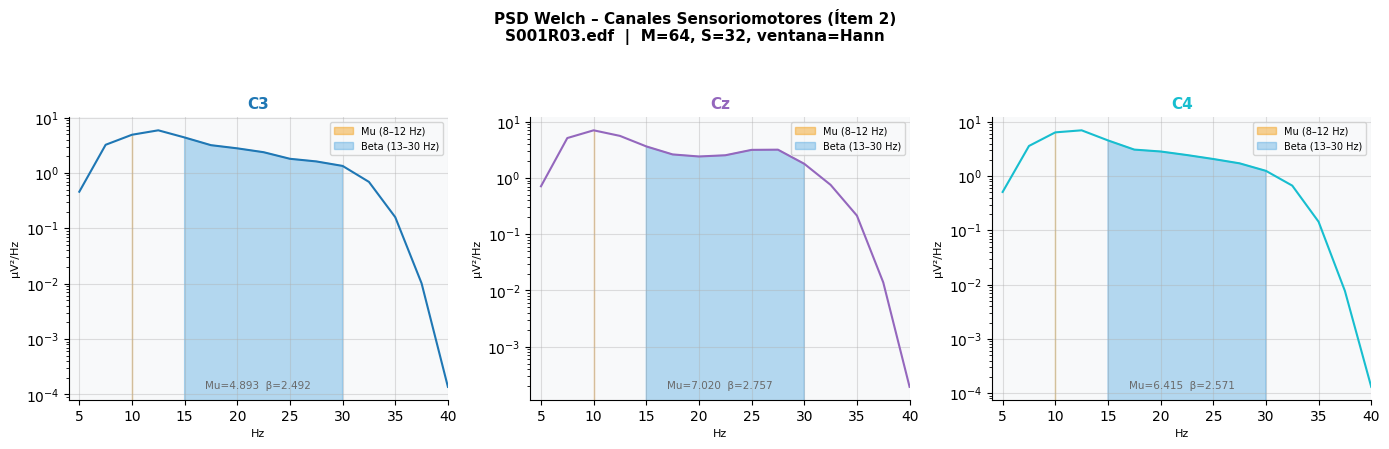

→ Figura guardada: figuras_BCI/paso4_PSD_canales.png


In [34]:
def calcular_psd_todos_canales(epochs, canales, M=64, S=32, ventana='hann'):
    """
    Calcula la PSD promedio (Welch manual) para un conjunto de canales
    y todas las épocas.
    Retorna dict {canal: (freqs, PSD_media)}
    """
    resultado = {}
    for ch in canales:
        if ch not in epochs.ch_names:
            continue
        idx = epochs.ch_names.index(ch)
        data_ch = epochs.get_data()[:, idx, :]   # (n_epocas, n_muestras)
        psds_ep = []
        for ep in data_ch:
            f, p, _ = welch_manual(ep, fs=sfreq, M=M, S=S, ventana=ventana)
            psds_ep.append(p)
        PSD_media = np.mean(np.array(psds_ep), axis=0) * 1e12  # µV²/Hz
        resultado[ch] = (f, PSD_media)
    return resultado

# ── Calcular para todos los canales de interés ───────────────────────
psd_canales = calcular_psd_todos_canales(
    epochs_ref, CANALES_INTERES, M=M_welch, S=S_welch
)

print(f"✔ PSD calculada para {len(psd_canales)} canales")
for ch, (f, p) in psd_canales.items():
    pot_mu   = p[(f>=8)  & (f<=12)].mean()
    pot_beta = p[(f>=13) & (f<=30)].mean()
    print(f"  {ch:6s} → Pot. Mu={pot_mu:.3f}  β={pot_beta:.3f}  µV²/Hz")

# ── Gráfica: grilla 3×3 de canales ───────────────────────────────────
n_ch_plot = len(psd_canales)
ncols, nrows = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 11), sharey=False)
axes_flat  = axes.flatten()
PALETA     = plt.cm.tab10(np.linspace(0, 0.9, n_ch_plot))

for i, (ch, (f_ch, p_ch)) in enumerate(psd_canales.items()):
    ax    = axes_flat[i]
    color = PALETA[i]
    mask  = (f_ch >= 4) & (f_ch <= 40)
    f_plot = f_ch[mask]          # mismo subconjunto 4-40 Hz
    p_plot = p_ch[mask]
    ax.semilogy(f_plot, p_plot, color=color, lw=1.5)
    ax.fill_between(f_plot, p_plot,
                where=(f_plot >= 8) & (f_plot <= 12), alpha=0.10, color=color)

    # Sombrear bandas Mu y Beta
    # CORRECCIÓN: usar f_ch[mask] (mismo vector que se usó en semilogy)
    # y where referido también a ese subconjunto — así los índices coinciden
    f_plot = f_ch[mask]
    p_plot = p_ch[mask]
    mask_mu_plot   = (f_plot >= 8)  & (f_plot <= 12)
    mask_beta_plot = (f_plot >= 13) & (f_plot <= 30)

    ax.fill_between(f_plot, p_plot, where=mask_mu_plot,   alpha=0.45,
                    color='#F39C12', label='Mu (8–12 Hz)')
    ax.fill_between(f_plot, p_plot, where=mask_beta_plot, alpha=0.35,
                    color='#3498DB', label='Beta (13–30 Hz)')

    ax.set_title(ch, fontweight='bold', color=color, fontsize=11)
    ax.set_xlabel('Hz', fontsize=8)
    ax.set_ylabel('µV²/Hz', fontsize=8)
    ax.set_xlim([4, 40])
    ax.legend(fontsize=7, loc='upper right')

    pot_mu   = p_plot[mask_mu_plot].mean()
    pot_beta = p_plot[mask_beta_plot].mean()
    ax.annotate(f'Mu={pot_mu:.3f}  β={pot_beta:.3f}',
                xy=(0.5, 0.04), xycoords='axes fraction',
                ha='center', fontsize=7.5, color='dimgray')

for j in range(n_ch_plot, nrows*ncols):
    axes_flat[j].set_visible(False)

fig.suptitle(
    f'PSD Welch – Canales Sensoriomotores (Ítem 2)\n'
    f'{os.path.basename(archivos[0])}  |  M={M_welch}, S={S_welch}, ventana=Hann',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('figuras_BCI/paso4_PSD_canales.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura guardada: figuras_BCI/paso4_PSD_canales.png")


In [5]:
import os
import glob
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. FUNCIÓN DE PROCESAMIENTO (CON GRÁFICAS OPCIONALES)
# =====================================================================
def procesar_flujo_bci(ruta_edf, plot_steps=False):
    """Aplica el pipeline: CAR -> Filtro FIR (8-30Hz) -> Epochs -> Welch PSD"""
    raw = mne.io.read_raw_edf(ruta_edf, preload=True, verbose='WARNING')
    raw.rename_channels(lambda x: x.strip('.'))
    if plot_steps:
        raw.plot(duration=4, n_channels=10, title="Fase 0: Señal Cruda")
        plt.show()

    raw_car, _ = mne.set_eeg_reference(raw, ref_channels='average', copy=True, verbose='WARNING')
    if plot_steps:
        raw_car.plot(duration=4, n_channels=10, title="Fase 1: CAR")
        plt.show()

    raw_filtered = raw_car.copy().filter(l_freq=8.0, h_freq=30.0, method='fir', phase='zero', verbose='WARNING')
    if plot_steps:
        raw_filtered.plot(duration=4, n_channels=10, title="Fase 2: Filtrada")
        plt.show()

    events, event_id = mne.events_from_annotations(raw_filtered, verbose='WARNING')
    epochs = mne.Epochs(raw_filtered, events, tmin=-0.2, tmax=1.0, baseline=(None, 0), preload=True, verbose='WARNING')
    if plot_steps:
        epochs.plot(n_epochs=4, n_channels=10, title="Fase 3: Épocas")
        plt.show()

    spectrum = epochs.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose='WARNING')
    if plot_steps:
        spectrum.plot(average=True)
        plt.show()

    return epochs, spectrum

# =====================================================================
# 2. FUNCIÓN PARA EXTRAER LA POTENCIA EN LAS BANDAS MU Y BETA
# =====================================================================
def extraer_potencia_bandas(spectrum, canales_interes=['C3', 'C4']):
    """Calcula la potencia promedio en las bandas Mu y Beta para canales específicos."""
    psds, freqs = spectrum.get_data(return_freqs=True)
    ch_names = spectrum.ch_names
    
    idx_mu = np.where((freqs >= 8) & (freqs <= 13))[0]
    idx_beta = np.where((freqs >= 13) & (freqs <= 30))[0]
    
    resultados = {}
    for ch in canales_interes:
        if ch in ch_names:
            ch_idx = ch_names.index(ch)
            potencia_mu = np.mean(psds[:, ch_idx, idx_mu])
            potencia_beta = np.mean(psds[:, ch_idx, idx_beta])
            
            resultados[f'Potencia mu {ch}'] = potencia_mu
            resultados[f'Potencia beta {ch}'] = potencia_beta
        else:
            resultados[f'Potencia mu {ch}'] = np.nan
            resultados[f'Potencia beta {ch}'] = np.nan
            
    return resultados

# =====================================================================
# 3. RUTINA PRINCIPAL: RECORRIDO SOLO PARA 2 SUJETOS
# =====================================================================

# Define tu ruta base
ruta_base = r"C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files"

# LISTA DE SUJETOS DE PRUEBA (Solo 2 sujetos para empezar)
sujetos_prueba = ["S001", "S002"]

archivos_encontrados = []

# Recorremos solo los sujetos de la lista
for sujeto in sujetos_prueba:
    # Patrón para buscar R03 y R04 dentro de la carpeta de ese sujeto específico
    patron = os.path.join(ruta_base, sujeto, "*R0[34].edf")
    archivos_encontrados.extend(glob.glob(patron))

print(f"Se encontraron {len(archivos_encontrados)} archivos para procesar (deberían ser 4 en total).")

lista_datos = []

for archivo in archivos_encontrados:
    nombre_archivo = os.path.basename(archivo) 
    registro_sujeto = nombre_archivo[:4]       
    
    if "R03" in nombre_archivo:
        tarea = "Movimiento Real"
    elif "R04" in nombre_archivo:
        tarea = "Imaginacion Motora"
    else:
        continue

    try:
        # Procesamos sin gráficas
        epochs, spectrum = procesar_flujo_bci(archivo, plot_steps=False)
        potencias = extraer_potencia_bandas(spectrum, canales_interes=['C3', 'C4'])
        
        fila = {
            "Registro": registro_sujeto,
            "Tarea": tarea
        }
        fila.update(potencias) 
        
        lista_datos.append(fila)
        print(f"Procesado exitosamente: {nombre_archivo}")
        
    except Exception as e:
        print(f"Error procesando {nombre_archivo}: {e}")

# Convertimos a DataFrame
df_resultados = pd.DataFrame(lista_datos)

print("\n--- Vista previa del DataFrame final (Prueba con 2 sujetos) ---")
print(df_resultados)

Se encontraron 4 archivos para procesar (deberían ser 4 en total).
Procesado exitosamente: S001R03.edf
Procesado exitosamente: S001R04.edf
Procesado exitosamente: S002R03.edf
Procesado exitosamente: S002R04.edf

--- Vista previa del DataFrame final (Prueba con 2 sujetos) ---
  Registro               Tarea  Potencia mu C3  Potencia beta C3  \
0     S001     Movimiento Real    5.806909e-12      2.660597e-12   
1     S001  Imaginacion Motora    6.212061e-12      2.693099e-12   
2     S002     Movimiento Real    3.831606e-12      1.549218e-12   
3     S002  Imaginacion Motora    4.199625e-12      1.452576e-12   

   Potencia mu C4  Potencia beta C4  
0    7.085102e-12      2.986616e-12  
1    5.441890e-12      2.284265e-12  
2    3.089029e-12      9.891992e-13  
3    2.259715e-12      9.549128e-13  
